In [1]:
import scipy.io
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from collections import Counter


import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Subset, Dataset, DataLoader
import torch.optim as optim

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Model Class implementation and training function

In [3]:
class EEGNet(nn.Module):
    def __init__(self, num_classes=7, num_channels=24, input_samples=1500, dropout_rate=0.25, kernel_length=64, F1=8, D=2, F2=16):
        super(EEGNet, self).__init__()

        self.num_classes = num_classes

        self.firstConv = nn.Sequential(
            nn.Conv2d(1, F1, kernel_size=(1,kernel_length), padding=(0, kernel_length//2), bias=False),
            nn.BatchNorm2d(F1)
        )

        self.depthwiseConv = nn.Sequential(
            nn.Conv2d(F1, F1*D, kernel_size=(num_channels, 1), groups=F1, bias=False),
            nn.BatchNorm2d(F1*D),
            nn.ELU(),
            nn.AvgPool2d(kernel_size=(1,4)),
            nn.Dropout(p=dropout_rate)
        )

        self.separableConv = nn.Sequential(
            nn.Conv2d(F1*D, F2, kernel_size=(1,16), padding=(0,8), bias=False),
            nn.BatchNorm2d(F2),
            nn.ELU(),
            nn.AvgPool2d(kernel_size=(1,8)),
            nn.Dropout(p=dropout_rate)
        )

        with torch.no_grad():
            dummy = torch.zeros(1, 1, num_channels, input_samples)
            x = self.firstConv(dummy)
            x = self.depthwiseConv(x)
            x = self.separableConv(x)
            # print (x.shape)
            flattened = x.shape[1] * x.shape[2] * x.shape[3]


        self.classify = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flattened, num_classes)
        )

    def forward(self, x):
        x = self.firstConv(x)
        x = self.depthwiseConv(x)
        x = self.separableConv(x)
        x = self.classify(x)
        return x

In [4]:
# Train and evaluate
def train(model, train_loader, criterion, optimizer, device):
    model.train()
    total_loss = 0

    for X,y in train_loader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        out = model(X)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    return total_loss / len(train_loader)

def evaluate(model, test_loader, device):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for X, y in test_loader:
            X,y = X.to(device), y.to(device)
            out = model(X)
            pred = out.argmax(dim=1)  # FIXED: Changed from argmin to argmax

            correct += (pred == y).sum().item()
            total += y.size(0)

    return correct / total

def evaluateFinal(model, test_loader, device):
    model.eval()
    correct, total = 0, 0

    actual = torch.tensor([])
    predicted = torch.tensor([])
    with torch.no_grad():
        for X, y in test_loader:
            X,y = X.to(device), y.to(device)
            out = model(X)
            pred = out.argmax(dim=1)  # FIXED: Changed from argmin to argmax

            correct += (pred == y).sum().item()
            total += y.size(0)

            actual = torch.cat((actual, y.cpu()), dim=0)
            predicted = torch.cat((predicted, pred.cpu()), dim=0)

        print(np.unique(predicted.numpy(), return_counts=True))

        cm = confusion_matrix(actual.numpy(), predicted.numpy())
        ConfusionMatrixDisplay(cm).plot()

    print(f"The accuracy for the test is {(correct / total)*100:.2f}%")

    return correct / total

In [5]:
# DataLoader with proper data type handling

class BCIDataset(Dataset):
    def __init__(self, X, y):
        # Ensure proper data types to avoid kernel crashes
        # X should be float32, y should be int64 (long)
        self.X = torch.from_numpy(X.astype(np.float32))
        self.y = torch.from_numpy(y.astype(np.int64))

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Load the data

The first thing we need to do is to load the data from our input file and check its content to make suure that we are aactually loading complete data

In [6]:
def load_data_method_1(file_path):
    """
    Original method - iterates gesture_type then row
    """
    mat_file = scipy.io.loadmat(file_path)
    cell_array = mat_file["combinedCell"]
    # print(mat_file.keys())

    X, Y = [], []
    num_classes = cell_array.shape[1]
    num_training_ex = cell_array.shape[0]

    print("num_classes", num_classes)
    print("num_training_ex", num_training_ex)

    for gesture_type in range(num_classes):
        for row_idx in range(num_training_ex):
            cell = cell_array[row_idx, gesture_type]
            cell = np.array(cell)
            X.append(cell.astype(np.float32))
            Y.append(gesture_type)

    return np.array(X), np.array(Y)

In [7]:
# Load the .mat file
# file_path = "E:/Chris/EMG/Data/put_emg_model_data.mat"
file_path = '/Users/chrisdollo/Documents/Research/putEMG prime/Data/combined_per_per_subject/uniformized_emg_gestures_03_combined_non_uniform.mat'
file_path = '/Users/chrisdollo/Documents/Research/putEMG prime/Data/data_5_subjects/total/data_for_5_subject.mat'


# parttial dataset
#file_path = "E:/Chris/EMG/Data/put_emg_model_data.mat"
# file_path = "E:/Chris/EMG/Data/data_for_5_subject.mat"
# file_path = "E:/Chris/EMG/Data/uniform_mat_data_per_subject/uniformized_emg_gestures_15_combined_non_uniform.mat"
# file_path="E:/Chris/EMG/Data/uniform_mat_data_per_subject/uniformized_emg_gestures_20_combined_non_uniform.mat"

X, Y = load_data_method_1(file_path)

num_classes 7
num_training_ex 200


In [28]:
# checking for unique values
print(f"X shape: {X.shape}")
print(f"y shape: {Y.shape}")
print(f"Those are the unique label values {np.unique(Y, return_counts=True)}")

X shape: (1400, 1500, 24)
y shape: (1400,)
Those are the unique label values (array([0, 1, 2, 3, 4, 5, 6]), array([200, 200, 200, 200, 200, 200, 200]))


2. Prepare the data for training

Here we need to get the data in a format that works with our model.
Our model takes on 4-Dimensional input so we need to add a new dimension to our training example.

We then need to split the data in training and testing set. We'll do 20% for testing and 80% for training

Finally, we need to pass the data to our pre-define data loaders so that it can be used to train the model

In [8]:
# adding an extra dimention to our training example
X = X[:, np.newaxis, :, :]
X = np.transpose(X, (0, 1, 3, 2))

Y= Y.squeeze()
Y = Y.astype(np.int64)

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size = 0.2, stratify=Y, random_state=42)

train_ds = BCIDataset(X_train,y_train)

In [9]:
labels = {}
for i in y_test:
    if i in labels:
        labels[i] +=1
    else:
        labels[i]=1
print(labels)

{np.int64(5): 40, np.int64(1): 40, np.int64(3): 40, np.int64(6): 40, np.int64(2): 40, np.int64(0): 40, np.int64(4): 40}


# Model validation and Training

Now we can create the model and start training

In [35]:
# Set up for cross validation
K = 5
skf = StratifiedKFold(n_splits = K, shuffle=True, random_state=42)
indices = np.arange(len(train_ds))


# Hyperparameters to try to fine-tune the data
# dropouts = [i/100 for i in range(10, 50, 10)]
# learning_rates = [i/1000 for i in range(5, 125, 25)]
dropouts = [0.1]
learning_rates = [1e-3]
dropouts = [0.1, 0.2, 0.3]
# learning_rates = [5e-4, 1e-4, 3e-4, 1e-3]

In [36]:
def create_mod(train_loader, val_loader, learning_rate, dropout_rate, device):

    # initialize the model with the dropout rate and the learning rate
    model = EEGNet(num_classes= 7, num_channels=24, input_samples=1500, dropout_rate=dropout_rate)
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    criterion = nn.CrossEntropyLoss()

    # stats variable
    max_epochs = 15
    patience = 7
    min_delta = 0.005

    true_best = float("-inf")   # strict best (any improvement)
    es_best   = float("-inf")   # meaningful best (improvement >= min_delta)
    mx_acc_model = 0
    bad_epochs = 0
    epochs = 0

    # training loop
    while(epochs < max_epochs):
        
        loss = train(model, train_loader, criterion, optimizer, device)
        acc = evaluate(model, val_loader, device)

        if acc > true_best:
            true_best = acc

        if acc > (es_best + min_delta):
            es_best = acc
            bad_epochs = 0
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        else:
            bad_epochs += 1 
            
        print(f"Epoch {epochs}: Loss= {loss:.4f}, Accuracy: {acc*100:.2f}%, Max Acc: {mx_acc_model*100:.2f} "
              f"TrueBest={true_best*100:.2f}%, ESBest={es_best*100:.2f}%, "
            )

        if bad_epochs >= patience:
            print("Stopping Early ....")
            break 

        epochs+=1
    

    return es_best


In [37]:
max_accuracy = 0
best_model_weights = None
best_lr = 0
best_dropout = 0


for lr in learning_rates:
    for dropout in dropouts:

        fold_acc = []               # keeps track of all accuracies got for the fold
        best_acc_for_lr_dr = 0      # keeps track of best accuracy for a specific combination of learning rate and dropout

        # we create set up the different folds
        for fold, (train_idx, val_idx) in enumerate(skf.split(indices, y_train), 1):

            # print(f"Fold {fold}, dropout:{dropout}, lr = {lr}")

            # for each fold we use part of our set as training set and the other part as validation
            train_subset = Subset(train_ds, train_idx)
            val_subset = Subset(train_ds, val_idx)

            train_loader = DataLoader(train_subset, batch_size=16, shuffle=True)
            val_loader = DataLoader(val_subset, batch_size=16, shuffle=False)

            # training function
            accuracy_for_lr_dr_fld = create_mod(train_loader, val_loader, lr, dropout, device)
            fold_acc.append(accuracy_for_lr_dr_fld)
            

            if accuracy_for_lr_dr_fld > best_acc_for_lr_dr:
                best_acc_for_lr_dr = accuracy_for_lr_dr_fld
        
        mean_fold_acc = np.mean(fold_acc)
        
        if mean_fold_acc > max_accuracy:
            print("Better hyperparameters found")
            best_dropout = dropout
            best_lr = lr
            max_accuracy = mean_fold_acc

        print("--------------")
        print(f"Best accuracy for combo of learning rate and dropout = {best_acc_for_lr_dr}")
        print(f"Accuracies for the entire fold {fold_acc}")
        print(f"Mean accuracy for the fold {mean_fold_acc}")
        print("--------------")


Epoch 0: Loss= 1.7822, Accuracy: 29.91%, Max Acc: 0.00 TrueBest=29.91%, ESBest=29.91%, 
Epoch 1: Loss= 1.3989, Accuracy: 44.64%, Max Acc: 0.00 TrueBest=44.64%, ESBest=44.64%, 
Epoch 2: Loss= 1.1618, Accuracy: 55.36%, Max Acc: 0.00 TrueBest=55.36%, ESBest=55.36%, 
Epoch 3: Loss= 1.0094, Accuracy: 61.61%, Max Acc: 0.00 TrueBest=61.61%, ESBest=61.61%, 
Epoch 4: Loss= 0.9108, Accuracy: 58.48%, Max Acc: 0.00 TrueBest=61.61%, ESBest=61.61%, 
Epoch 5: Loss= 0.8506, Accuracy: 60.71%, Max Acc: 0.00 TrueBest=61.61%, ESBest=61.61%, 
Epoch 6: Loss= 0.7588, Accuracy: 57.14%, Max Acc: 0.00 TrueBest=61.61%, ESBest=61.61%, 
Epoch 7: Loss= 0.6962, Accuracy: 63.84%, Max Acc: 0.00 TrueBest=63.84%, ESBest=63.84%, 
Epoch 8: Loss= 0.6718, Accuracy: 64.29%, Max Acc: 0.00 TrueBest=64.29%, ESBest=63.84%, 
Epoch 9: Loss= 0.6841, Accuracy: 62.05%, Max Acc: 0.00 TrueBest=64.29%, ESBest=63.84%, 
Epoch 10: Loss= 0.5846, Accuracy: 64.29%, Max Acc: 0.00 TrueBest=64.29%, ESBest=63.84%, 
Epoch 11: Loss= 0.5792, Accurac

In [39]:
print(f"best_dropout = {best_dropout } "
        f"best_lr = {best_lr} "
        f"max_accuracy = {max_accuracy} ")

best_dropout = 0.1 best_lr = 0.001 max_accuracy = 0.6491071428571429 


# Training a new model using the hyperparameters

In [10]:
best_dropout = 0.1
best_lr = 0.001

In [11]:
print(X_train.shape)
print(y_train.shape)

(1120, 1, 24, 1500)
(1120,)


In [12]:
train_ds = BCIDataset(X_train, y_train)
val_ds = BCIDataset(X_test, y_test)

train_final_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
val_final_loader = DataLoader(val_ds, batch_size=16, shuffle=False)

model_final = EEGNet(num_classes= 7, num_channels=24, input_samples=1500, dropout_rate=best_dropout)
model_final = model_final.to(device)
optimizer = optim.Adam(model_final.parameters(), lr=best_lr)
criterion = nn.CrossEntropyLoss()


mx_acc = 0
for epoch in range(12):
    loss = train(model_final, train_final_loader, criterion, optimizer, device)
    acc = evaluate(model_final, val_final_loader, device)
    if acc > mx_acc:
        mx_acc = acc
    print(f"Epoch {epoch}: Loss= {loss:.4f}, Accuracy: {acc*100:.2f}%, Max Acc: {mx_acc*100:.2f}")

Epoch 0: Loss= 1.7553, Accuracy: 36.43%, Max Acc: 36.43
Epoch 1: Loss= 1.3485, Accuracy: 46.07%, Max Acc: 46.07
Epoch 2: Loss= 1.1265, Accuracy: 50.00%, Max Acc: 50.00
Epoch 3: Loss= 0.9859, Accuracy: 57.50%, Max Acc: 57.50
Epoch 4: Loss= 0.8820, Accuracy: 54.64%, Max Acc: 57.50
Epoch 5: Loss= 0.8233, Accuracy: 56.43%, Max Acc: 57.50
Epoch 6: Loss= 0.7722, Accuracy: 57.14%, Max Acc: 57.50
Epoch 7: Loss= 0.7713, Accuracy: 55.36%, Max Acc: 57.50
Epoch 8: Loss= 0.6667, Accuracy: 56.79%, Max Acc: 57.50
Epoch 9: Loss= 0.6664, Accuracy: 57.50%, Max Acc: 57.50
Epoch 10: Loss= 0.6069, Accuracy: 57.86%, Max Acc: 57.86
Epoch 11: Loss= 0.5907, Accuracy: 56.79%, Max Acc: 57.86


# Evaluation phase

(array([0., 1., 2., 3., 4., 5., 6.], dtype=float32), array([152, 153, 159, 118, 238, 116, 184]))
The accuracy for the test is 82.95%


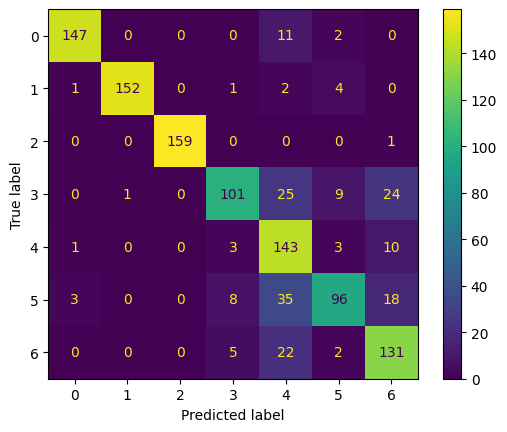

In [14]:
acc = evaluateFinal(model_final, train_final_loader, device)

(array([0., 1., 2., 3., 4., 5., 6.], dtype=float32), array([42, 27, 44, 25, 62, 33, 47]))
The accuracy for the test is 56.79%


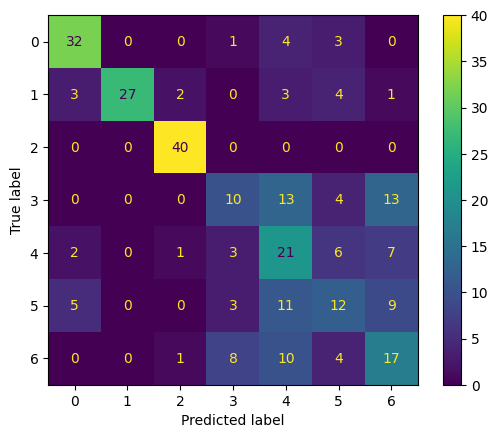

In [15]:
acc = evaluateFinal(model_final, val_final_loader, device)